# A DFN model for LG M50 cell to predict beginning-of-life (BOL) behaviour

In this example, we use in-built DFN model of PyBaMM for Lithium ion battery simulations. We also use the parameter set provided by Chen2020 in PyBaMM for LG M50 cell as the base set. First, we attempt to compare the model vs. experimental data of LG M50 cell at 0.2, 0.3, 0.4, 0.5C rates using default parameters of Chen2020. We then modify some of the parameters for our cell and simulate the model to compare with the experimental data at different C-rates.

In this notebook, we also compare the SPM, SPMe, and DFN models with Chen2020 parameters. Later, we test pybamm.Experiment class boundary conditions for CC-CV simulations. We then implement thermal modelling submodel. We implement temperature dependent diffusivity and entropic coefficients for thermal modelling. 

LG M50 cell is a lithium ion batter cell with NMC811 as the positive electrode and Graphite+Si as the negative electrode to offer high energy density. The experimental data of LG M50 cell is generated by Electrochemical Science and Engineering Group, Imperial College London.
https://www.imperial.ac.uk/electrochem-sci-eng

# With default Chen2020 parameters

/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/src/pybamm/simulation.py:122: UserWarning: The default solver changed to IDAKLUSolver after the v25.4.0. release. You can swap back to the previous default by using `pybamm.CasadiSolver()` instead.
  self._solver = solver or self._model.default_solver


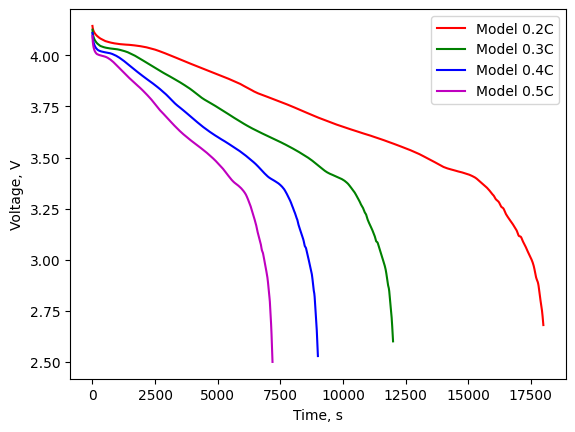

In [ ]:
##With default Chen2020 parameters




import matplotlib.pyplot as plt
import numpy as np

import pybamm

colors = ("r", "g", "b", "m")

def LG_M50_model(discharge): 
   
    model = pybamm.lithium_ion.DFN()
    params = pybamm.ParameterValues("OKane2022")
    sim = pybamm.Simulation(model=model, parameter_values=params, C_rate=discharge)
    sim.solve([0, 3600/discharge])
    return(
        sim.solution["Time [h]"].entries*3600,
        sim.solution["Terminal voltage [V]"].entries
        )
 
    
for i, discharge in enumerate((0.2, 0.3, 0.4, 0.5)):
   
    model = LG_M50_model(discharge)
    #experiment = np.loadtxt(f"BOL_Crate_data_LGM50Imperial/0{int(10*discharge)}Cedit.txt").T
    plt.plot(*model, color=colors[i], linestyle="-", label=f"Model {discharge}C")
    #plt.plot(*experiment, color=colors[i], linestyle="--", label=f"Exp {discharge}C")


plt.xlabel("Time, s")
plt.ylabel("Voltage, V")
plt.legend()
plt.show()

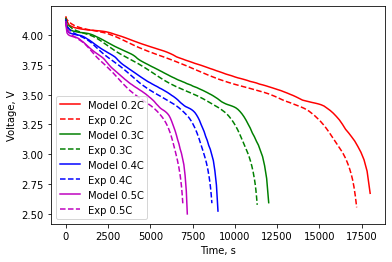

In [ ]:
##With default Chen2020 parameters

"""LG M50 cell beginning-of-life model. 
DFN model was used for P2D model simulations. 
Chen2020 parameters were used as the base parameters. """


import matplotlib.pyplot as plt
import numpy as np

import pybamm

colors = ("r", "g", "b", "m")

def LG_M50_model(discharge): 
    """The LG_M50_model function solves the DFN model with Chen2020 parameters for LG M50 cell at a discharge 
     C-rate provided by 'discharge' input. The C-rate is converted into 'Current function [A]' using 
     'Cell capacity [A.h]' which will be updated in the parameters list. The function
    returns the solution of Terminal voltage vs. time."""
    model = pybamm.lithium_ion.DFN()
    params = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Chen2020)
    sim = pybamm.Simulation(model=model, parameter_values=params, C_rate=discharge)
    sim.solve([0, 3600/discharge])
    return(
        sim.solution["Time [h]"].entries*3600,
        sim.solution["Terminal voltage [V]"].entries
        )
 
    
for i, discharge in enumerate((0.2, 0.3, 0.4, 0.5)):
    """This is a 'for loop' to call LG_M50_model funtion for different C-rates and get the Voltage vs. time data
    as output. For each i, the model simulates and compares the solution data with experimental data at given C-rate"""
    model = LG_M50_model(discharge)
    experiment = np.loadtxt(f"BOL_Crate_data_LGM50Imperial/0{int(10*discharge)}Cedit.txt").T
    plt.plot(*model, color=colors[i], linestyle="-", label=f"Model {discharge}C")
    plt.plot(*experiment, color=colors[i], linestyle="--", label=f"Exp {discharge}C")


plt.xlabel("Time, s")
plt.ylabel("Voltage, V")
plt.legend()
plt.show()

# With updated parameters

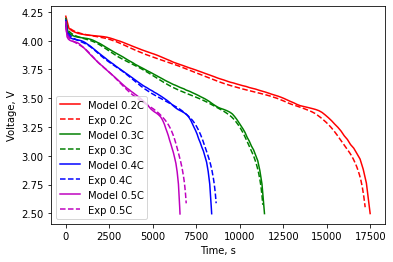

In [4]:
"""LG M50 cell beginning-of-life model with modified parameters. 
DFN model was used for P2D model simulations.  
Chen2020 parameters were used as the base parameters. 
Few parameters of Chen2020 were modified to ensure proper capacity balanced cell. 
"""

import matplotlib.pyplot as plt
import numpy as np

import pybamm

colors = ("r", "g", "b", "m")

def LG_M50_model(discharge):
    """ The LG_M50_model function solves the DFN model with updated Chen2020 parameters
    for LG M50 cell at a discharge C-rate provided by 'discharge' input. Some of the parameters
    are updated to maintain the cell balancing as given below. The C-rate is converted into 
    'Current function [A]' using 'Cell capacity [A.h]' which will be updated in the parameters list. The function
    returns the solution data of Terminal voltage vs. time."""


    model = pybamm.lithium_ion.DFN()
    params = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Chen2020)
    params.update({"Initial concentration in negative electrode [mol.m-3]": 29866})
    params.update({"Initial concentration in positive electrode [mol.m-3]": 14778})
    params.update({"Maximum concentration in negative electrode [mol.m-3]": 33133})
    params.update({"Maximum concentration in positive electrode [mol.m-3]": 56840})
    params.update({"Negative electrode diffusivity [m2.s-1]": 3.3e-15})
   
    sim = pybamm.Simulation(model=model, parameter_values=params, C_rate=discharge)
    sim.solve([0, 3600/discharge])
    return(
        sim.solution["Time [h]"].entries*3600,
        sim.solution["Terminal voltage [V]"].entries
    )
 
    
for i, discharge in enumerate((0.2, 0.3, 0.4, 0.5)):
    """This is a 'for loop' to call LG_M50_model funtion for different C-rates and get the Voltage vs. time data
    as output. For each i, the model simulates and compares the solution data with experimental data at given C-rate"""
    model = LG_M50_model(discharge)
    experiment = np.loadtxt(f"BOL_Crate_data_LGM50Imperial/0{int(10*discharge)}Cedit.txt").T
    plt.plot(*model, color=colors[i], linestyle="-", label=f"Model {discharge}C")
    plt.plot(*experiment, color=colors[i], linestyle="--", label=f"Exp {discharge}C")


plt.xlabel("Time, s")
plt.ylabel("Voltage, V")
plt.legend()
plt.show()

# CC-CV charing-CC discharging and cycling

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import pybamm

#conditions for simulating CCCV charging as in an experiment using `pybamm.Experiment` operator    
exp = pybamm.Experiment(["Discharge at 0.2C until 2.5V", "Rest for 1 hour", "Charge at 0.3C until 4.2V",
                                "Hold at 4.2V until 50mA",
] * 3)
model = pybamm.lithium_ion.DFN()

#update the parameters with appropriate values
params = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Chen2020)
params.update({"Initial concentration in negative electrode [mol.m-3]": 29866})
params.update({"Initial concentration in positive electrode [mol.m-3]": 14778})
params.update({"Maximum concentration in negative electrode [mol.m-3]": 33133})
params.update({"Maximum concentration in positive electrode [mol.m-3]": 56840})
params.update({"Negative electrode diffusivity [m2.s-1]": 3.3e-15})


#Simulation with exp CCCV conditions
sim = pybamm.Simulation(model=model, parameter_values=params, experiment=exp)
sim.solve()
sim.plot(["Terminal voltage [V]", "Current [A]"])

# Thermal modelling

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import pybamm

#passing options for full thermal modelling of the cell. For lumped model, change it to `x-lumped`
options = {"thermal": "x-full"}   


#conditions for simulating CCCV charging cycling as in an experiment using `pybamm.Experiment` operator
exp = pybamm.Experiment(["Discharge at 0.2C until 2.5V", "Rest for 1 hour", "Charge at 0.3C until 4.2V",
                                "Hold at 4.2V until 50mA",
] * 3)

#pass thermal modelling option to DFN model
model = pybamm.lithium_ion.DFN(options=options)


#update the parameters with appropriate values
params = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Chen2020)
params.update({"Initial concentration in negative electrode [mol.m-3]": 29866})
params.update({"Initial concentration in positive electrode [mol.m-3]": 14778})
params.update({"Maximum concentration in negative electrode [mol.m-3]": 33133})
params.update({"Maximum concentration in positive electrode [mol.m-3]": 56840})
params.update({"Negative electrode diffusivity [m2.s-1]": 3.3e-15})

#These definitions are unavilable in updates
params.update({"Negative current collector surface heat transfer coefficient [W.m-2.K-1]": 0, 
"Positive current collector surface heat transfer coefficient [W.m-2.K-1]": 0}, check_already_exists=False)

#simulations with the exp conditions
sim = pybamm.Simulation(model=model, parameter_values=params, experiment=exp)
sim.solve()
sim.plot(["Terminal voltage [V]", "Current [A]", "Cell temperature [K]", "Total heating [W.m-3]"])

"Note that the variable "X-averaged cell temperature [K]" is the scalar-valued lumped temperature, whereas the variable "Cell temperature [K]" is the value of the lumped temperature broadcasted across the whole cell domain. This type of behaviour is purposefully designed to allow easy comparison of different models and settings. For instance we may wish to compare a simulation that uses a lumped thermal model with a simulation that uses a full thermal model (i.e. one that solves the heat equation in the x-direction). When comparing these two model we could then plot the same variable "Cell temperature [K]" to compare the temperature throughout the cell." - PyBaMM example - using-model-options_thermal-example

# Comparison of SPM, SPMe, DFN thermal models during cycling

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import pybamm

#passing options for full thermal modelling of the cell. For lumped model, change it to `x-lumped`
options = {"thermal": "x-full"}    

#conditions for simulating CCCV charging cycling as in an experiment using `pybamm.Experiement` operator
exp = pybamm.Experiment(["Discharge at 1C until 2.5V", "Rest for 1 hour", "Charge at 1C until 4.2V",
                                "Hold at 4.2V until 50mA",
] * 3)

#Define a list of models for comparision with thermal modelling option
models = [
    pybamm.lithium_ion.SPM(options=options),
    pybamm.lithium_ion.SPMe(options=options),
    pybamm.lithium_ion.DFN(options=options),
]


#update the parameters with appropriate values
params = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Chen2020)
params.update({"Initial concentration in negative electrode [mol.m-3]": 29866})
params.update({"Initial concentration in positive electrode [mol.m-3]": 14778})
params.update({"Maximum concentration in negative electrode [mol.m-3]": 33133})
params.update({"Maximum concentration in positive electrode [mol.m-3]": 56840})
params.update({"Negative electrode diffusivity [m2.s-1]": 3.3e-15})

#t_eval=[0, 3700/discharge] #Use it for simulations with no experimental cycling

params.update({"Negative current collector surface heat transfer coefficient [W.m-2.K-1]": 0, 
"Positive current collector surface heat transfer coefficient [W.m-2.K-1]": 0}, check_already_exists=False)

#simulate each model in the list with exp boundary conditions and thermal modelling. Append the solution to sims array
#for plotting latter
sims = []
for model in models:
    sim = pybamm.Simulation(model=model, parameter_values=params, experiment=exp)
    sim.solve()
    sims.append(sim)

#plot the stored data in sims array for required variables    
pybamm.dynamic_plot(
    sims,
    output_variables =[
        "Current [A]",
        "Terminal voltage [V]",
        "X-averaged cell temperature [K]",
        "Total heating [W.m-3]"
    ]);
    

## Temperature dependent diffusivity using function parameters

In [ ]:
#With more custom parameters for thermal model

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline

import pybamm

#passing options for full thermal modelling of the cell. For lumped model, change it to `x-lumped`
options = {"thermal": "x-full"}    

#conditions for simulating CCCV charging cycling as in an experiment using `pybamm.Experiement` operator
exp = pybamm.Experiment(["Discharge at 1C until 2.5V", "Rest for 1 hour", "Charge at 1C until 4.2V",
                                "Hold at 4.2V until 50mA",
] * 3)

#Define a list of models for comparision with thermal modelling option
models = [
    pybamm.lithium_ion.SPM(options=options),
    pybamm.lithium_ion.SPMe(options=options),
    pybamm.lithium_ion.DFN(options=options),
]

#update the parameters with appropriate values
params = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Chen2020)
params.update({"Initial concentration in negative electrode [mol.m-3]": 29866})
params.update({"Initial concentration in positive electrode [mol.m-3]": 14778})
params.update({"Maximum concentration in negative electrode [mol.m-3]": 33133})
params.update({"Maximum concentration in positive electrode [mol.m-3]": 56840})
#params.update({"Negative electrode diffusivity [m2.s-1]": 3.3e-15})

#t_eval=[0, 3700/discharge] #Use it for simulations with no experimental cycling

params.update({"Negative current collector surface heat transfer coefficient [W.m-2.K-1]": 0, 
"Positive current collector surface heat transfer coefficient [W.m-2.K-1]": 0}, check_already_exists=False)


#param.update({"parameter name": "[function]function_name"}, path="path_from_where_to_load_function")
params.update({"Negative electrode diffusivity [m2.s-1]": "[function]graphite_LGM50_diffusivity_Chen2020edit"}, path="")
params.update({"Positive electrode diffusivity [m2.s-1]": "[function]nmc_LGM50_diffusivity_Chen2020edit"}, path="")

#simulate each model in the list with exp boundary conditions and thermal modelling. Append the solution to sims array
#for plotting latter
sims = []
for model in models:
    sim = pybamm.Simulation(model=model, parameter_values=params, experiment=exp)
    sim.solve()
    sims.append(sim)

#plot the stored data in sims array for required variables    
pybamm.dynamic_plot(
    sims,
    output_variables =[
        "Current [A]",
        "Terminal voltage [V]",
        "X-averaged cell temperature [K]",
        #"Cell temperature [K]",
        "Total heating [W.m-3]"
    ]);
    #"Cell temperature" shows uniform temperatuer across the cell, which is confusing. 
    #It was mentioned somewhere in the pybamm examples that it is for convenience 
    #of comparing SPM and DFN models. 
    #However, the reasons are not clear. It needs to be changed in my opinion to avoid confusion. 

## With entropic coefficients for thermal modelling using csv data interpolation - not working

In [ ]:
#With more custom parameters for thermal model
# Attempted to include entropic coefficients for thermal modelling 
#using csv data interpolation dUdT vs SoC

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline

import pybamm

#passing options for full thermal modelling of the cell. For lumped model, change it to `x-lumped`
options = {"thermal": "x-full"}    

#conditions for simulating CCCV charging cycling as in an experiment using `pybamm.Experiement` operator
exp = pybamm.Experiment(["Discharge at 1C until 2.5V", "Rest for 1 hour", "Charge at 1C until 4.2V",
                                "Hold at 4.2V until 50mA",
] * 3)

#Define a list of models for comparision with thermal modelling option
models = [
    pybamm.lithium_ion.SPM(options=options),
    pybamm.lithium_ion.SPMe(options=options),
    pybamm.lithium_ion.DFN(options=options),
]

#update the parameters with appropriate values
params = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Chen2020)
params.update({"Initial concentration in negative electrode [mol.m-3]": 29866})
params.update({"Initial concentration in positive electrode [mol.m-3]": 14778})
params.update({"Maximum concentration in negative electrode [mol.m-3]": 33133})
params.update({"Maximum concentration in positive electrode [mol.m-3]": 56840})
#params.update({"Negative electrode diffusivity [m2.s-1]": 3.3e-15})

#t_eval=[0, 3700/discharge] #Use it for simulations with no experimental cycling

params.update({"Negative current collector surface heat transfer coefficient [W.m-2.K-1]": 0, 
"Positive current collector surface heat transfer coefficient [W.m-2.K-1]": 0}, check_already_exists=False)


#param.update({"parameter name": "[function]function_name"}, path="path_from_where_to_load_function")
params.update({"Negative electrode diffusivity [m2.s-1]": "[function]graphite_LGM50_diffusivity_Chen2020edit"}, path="")
params.update({"Positive electrode diffusivity [m2.s-1]": "[function]nmc_LGM50_diffusivity_Chen2020edit"}, path="")


# Defining functions for entropy coefficients
def GraphiteSi_LGMJ1_entropic_change_Sturm2019(sto, c_n_max):
    # in this case we ignore c_n_max
    """
    LG MJ1 Cell entropic change (dUdT) data for Graphite+Si electrode as a function of
    SOC. The values are taken from [1].

    References
    ----------
    .. [1] Sturm, J., Rheinfeld, A., Zilberman, I., Spingler, F. B., Kosch, S., 
    Frie, F., & Jossen, A. (2019). Modeling and simulation of inhomogeneities in 
    a 18650 nickel-rich, silicon-graphite lithium-ion cell during fast charging. 
    Journal of Power Sources, 412(September 2018), 204–223. 
    https://doi.org/10.1016/j.jpowsour.2018.11.043 

    Parameters
    ----------
    sto: :class:`pybamm.Symbol`
        Electrode stochiometry
    c_n_max: :`pybamm.Symbol`
        Maximum concentration in negative electrode
        
    Returns
    -------
       
    """
    data_Graphite = pd.read_csv('GraphiteSi_LGMJ1_entropic_change_Sturm2019.csv', comment="#", skip_blank_lines=True, header=None).to_numpy()
    return pybamm.Interpolant(data_Graphite, sto)

def NMC811_LGMJ1_entropic_change_Sturm2019(sto, c_p_max):
    # in this case we ignore c_p_max
    """
    LG MJ1 Cell entropic change (dUdT) data for NMC811 electrode as a function of
    SOC. The values are taken from [1].

    References
    ----------
    .. [1] Sturm, J., Rheinfeld, A., Zilberman, I., Spingler, F. B., Kosch, S., 
    Frie, F., & Jossen, A. (2019). Modeling and simulation of inhomogeneities in 
    a 18650 nickel-rich, silicon-graphite lithium-ion cell during fast charging. 
    Journal of Power Sources, 412(September 2018), 204–223. 
    https://doi.org/10.1016/j.jpowsour.2018.11.043 

    Parameters
    ----------
    sto: :class:`pybamm.Symbol`
        Electrode stochiometry
    c_p_max: :`pybamm.Symbol`
        Maximum concentration in positive electrode
        
    Returns
    -------
       
    """
    data_NMC811 = pd.read_csv('NMC811_LGMJ1_entropic_change_Sturm2019.csv', comment="#", skip_blank_lines=True, header=None).to_numpy()
    return pybamm.Interpolant(data_NMC811, sto)


#param.update({"parameter name": "[data]data_name"}, path="path_from_where_to_load_the_data")

#params.update({"Negative electrode OCP entropic change [V.K-1]": GraphiteSi_LGMJ1_entropic_change_Sturm2019})
#params.update({"Positive electrode OCP entropic change [V.K-1]": NMC811_LGMJ1_entropic_change_Sturm2019})



#simulate each model in the list with exp boundary conditions and thermal modelling. Append the solution to sims array
#for plotting latter
sims = []
for model in models:
    sim = pybamm.Simulation(model=model, parameter_values=params, experiment=exp)
    sim.solve()
    sims.append(sim)

#plot the stored data in sims array for required variables    
pybamm.dynamic_plot(
    sims,
    output_variables =[
        "Current [A]",
        "Terminal voltage [V]",
        "X-averaged cell temperature [K]",
        "Total heating [W.m-3]"
    ]);
    